**Assignment 2**: More Visualisations

In [1]:
%run ../helper.py

Task 1: Visualizing distributions

I will continue with the dataset from the prior assignment

In [2]:
import pandas as pd
df = pd.read_csv("../data/data1.csv")

The idea is to first compare the distribution across 5 continents. Then dive deeper into one. 

Division into continents based on available countries in the data:

In [3]:
# Define region mappings
south_america = ['Argentina', 'Bolivia (Plurinational State of)', 'Brazil', 'Chile', 
                 'Colombia', 'Ecuador', 'Paraguay', 'Peru', 'Suriname', 'Uruguay', 
                 'Venezuela (Bolivarian Republic of)']

europe = ['Albania', 'Austria', 'Belarus', 'Belgium', 'Bosnia and Herzegovina', 
          'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Estonia', 
          'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland', 
          'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Montenegro', 
          'Netherlands (Kingdom of the)', 'North Macedonia', 'Norway', 'Poland', 
          'Portugal', 'Republic of Moldova', 'Romania', 'Russian Federation', 'Serbia', 
          'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Türkiye', 
          'Ukraine', 'United Kingdom']

asia = ['Afghanistan', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Brunei Darussalam', 
        'Cambodia', 'China', 'Georgia', 'India', 'Indonesia', 
        'Iran (Islamic Republic of)', 'Iraq', 'Israel', 'Japan', 'Jordan', 
        'Kazakhstan', 'Kuwait', 'Kyrgyzstan', "Lao People's Democratic Republic", 
        'Lebanon', 'Malaysia', 'Maldives', 'Mongolia', 'Myanmar', 'Nepal', 'Oman', 
        'Pakistan', 'Philippines', 'Qatar', 'Republic of Korea', 'Saudi Arabia', 
        'Singapore', 'Sri Lanka', 'State of Palestine', 'Syrian Arab Republic', 
        'Tajikistan', 'Thailand', 'United Arab Emirates', 'Uzbekistan', 'Viet Nam', 
        'Yemen']

north_america = ['Bahamas', 'Barbados', 'Belize', 'Bermuda', 'Canada', 'Costa Rica', 
                 'Cuba', 'El Salvador', 'Guatemala', 'Haiti', 'Honduras', 'Jamaica', 
                 'Mexico', 'Nicaragua', 'Panama', 'Saint Lucia', 
                 'Trinidad and Tobago', 'United States of America']

africa = ['Algeria', 'Angola', 'Botswana', 'Burundi', 'Cabo Verde', 'Cameroon', 
          'Central African Republic', 'Congo', "Côte d'Ivoire", 'Egypt', 'Eritrea', 
          'Eswatini', 'Ethiopia', 'Gabon', 'Gambia', 'Ghana', 'Kenya', 
          'Madagascar', 'Malawi', 'Mauritius', 'Morocco', 'Mozambique', 'Namibia', 
          'Niger', 'Nigeria', 'Rwanda', 'Senegal', 'South Africa', 'Tunisia', 
          'Uganda', 'United Republic of Tanzania', 'Zambia', 'Zimbabwe']

In [4]:
# Create region column
def assign_region(country):
    if country in south_america:
        return 'South America'
    elif country in europe:
        return 'Europe'
    elif country in asia:
        return 'Asia'
    elif country in north_america:
        return 'North America'
    elif country in africa:
        return 'Africa'
    return None

Distribution variable: Manufacturing value added per capita. Filtering data accordingly:

In [5]:
# Filter for MVA per capita, most recent year, and assign regions
df_mva = df[(df['Variable'] == 'Manufacturing value added per capita') & 
            (df['Year'] == 2023)].copy()
df_mva['Region'] = df_mva['Country'].apply(assign_region)
df_mva = df_mva.dropna(subset=['Region'])

Creating first distribution plot, log-scale y-axis:

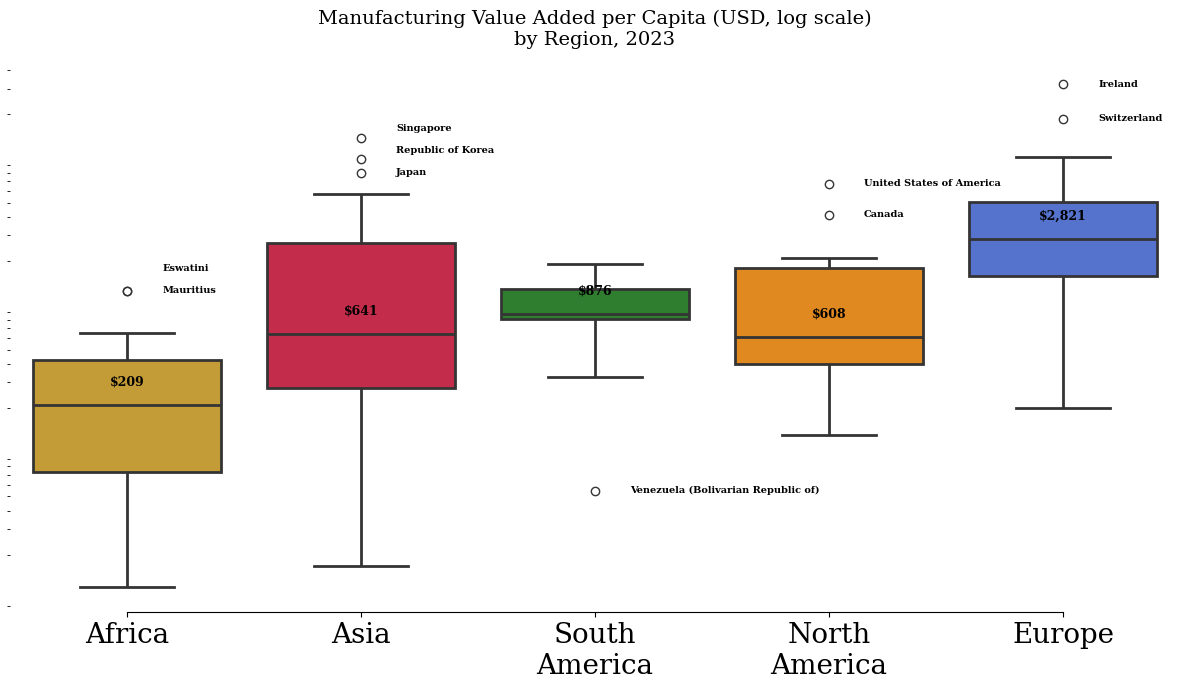

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

order = ['Africa', 'Asia', 'South America', 'North America', 'Europe']

region_colors = {
    'Africa': 'goldenrod',
    'Asia': 'crimson',
    'Europe': 'royalblue',
    'North America': 'darkorange',
    'South America': 'forestgreen'
}

sns.boxplot(
    data=df_mva,
    x='Region',
    y='Value',
    hue='Region',
    palette=region_colors,
    legend=False,
    linewidth=2,
    order=order
)

ax.set_yscale('log')
ax.set_xlabel("")
ax.set_ylabel("")

# Remove y-axis ticks and labels completely
ax.set_yticks([])
ax.set_yticklabels([])

# Split two-word region names onto separate lines
ax.set_xticks(range(len(order)))
ax.set_xticklabels([r.replace(' ', '\n') for r in order])

plt.title("Manufacturing Value Added per Capita (USD, log scale)\nby Region, 2023",
          fontsize=14, fontweight='light', pad=10)

sns.despine(fig, left=True, trim=True)

# Display medians centered above the median line
medians = df_mva.groupby('Region')['Value'].median()
for i, region in enumerate(order):
    med = medians[region]
    ax.text(i, med * 1.3, f'${med:,.0f}',
            va='bottom', ha='center',
            fontsize=9, fontweight='bold')

# Label outliers
for i, region in enumerate(order):
    subset = df_mva[df_mva['Region'] == region]
    q1 = subset['Value'].quantile(0.25)
    q3 = subset['Value'].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr

    outliers = subset[(subset['Value'] > upper) | (subset['Value'] < lower)]
    outliers = outliers.sort_values('Value')

    prev_y = None
    min_gap = 0.15

    for _, row in outliers.iterrows():
        y = np.log10(row['Value']) if row['Value'] > 0 else 0

        if prev_y is not None and abs(y - prev_y) < min_gap:
            y = prev_y + min_gap

        prev_y = y

        #ax.text(i + 0.15, 10**y, f"{row['Country']} (${row['Value']:,.0f})", 
        #fontsize=7, fontweight='semibold', va='center', ha='left')

        ax.text(i + 0.15, 10**y, f"{row['Country']}", 
        fontsize=7, fontweight='semibold', va='center', ha='left')

plt.tight_layout()
plt.savefig("../figures/boxplot-mva-regions.pdf", bbox_inches="tight", transparent=True)
plt.show()

Creating first distribution plot, regular y-axis:

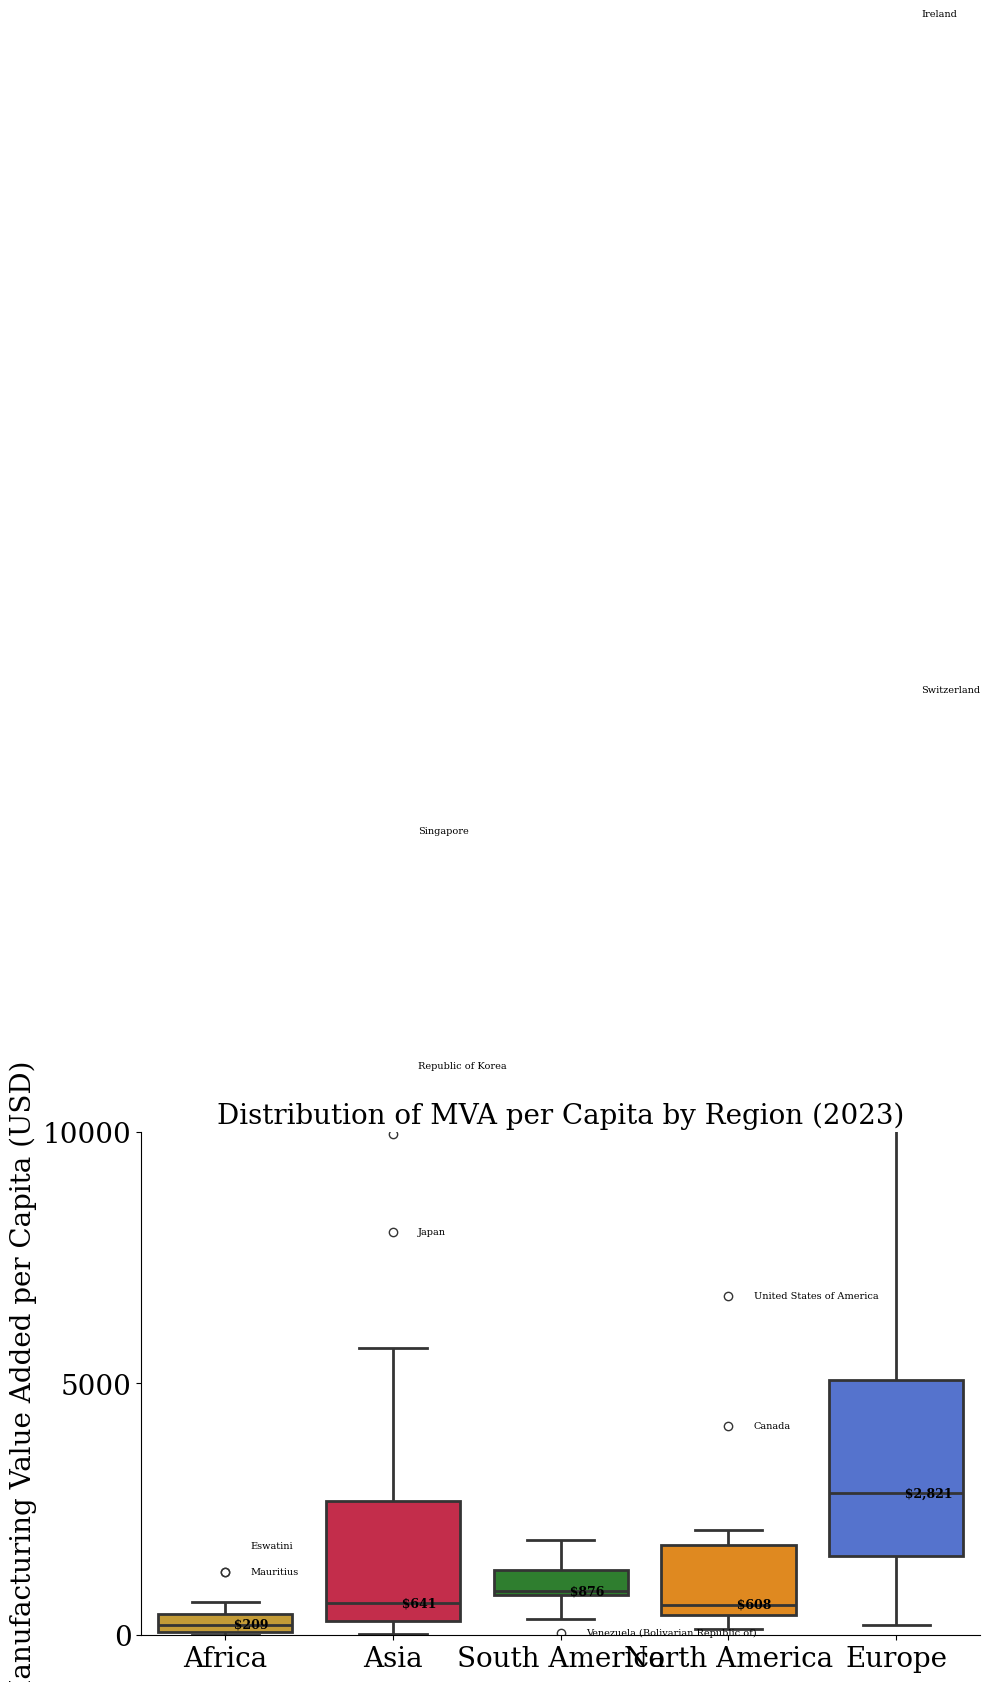

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

sns.boxplot(
    data=df_mva,
    x='Region',
    y='Value',
    hue='Region',
    palette=region_colors,
    legend=False,
    linewidth=2,
    order=['Africa', 'Asia', 'South America', 'North America', 'Europe']
)

ax.set_ylabel("Manufacturing Value Added per Capita (USD)")
#ax.set_yscale('log')
ax.set_ylim(0, 10000)
ax.set_yticks(np.arange(0,15000,5000))
ax.set_xlabel("")
plt.title("Distribution of MVA per Capita by Region (2023)")
sns.despine(fig)
plt.tight_layout()
plt.savefig("../figures/boxplot-mva-regions.pdf", bbox_inches="tight", transparent=True)

# Calculate and display medians
medians = df_mva.groupby('Region')['Value'].median()
order = ['Africa', 'Asia', 'South America', 'North America', 'Europe']

for i, region in enumerate(order):
    med = medians[region]
    ax.text(i, med, f'  ${med:,.0f}', 
            va='center', ha='left', 
            fontsize=9, fontweight='bold', color='black')

# Identify and label outliers
order = ['Africa', 'Asia', 'South America', 'North America', 'Europe']

for i, region in enumerate(order):
    subset = df_mva[df_mva['Region'] == region]
    q1 = subset['Value'].quantile(0.25)
    q3 = subset['Value'].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr
    
    outliers = subset[(subset['Value'] > upper) | (subset['Value'] < lower)]
    outliers = outliers.sort_values('Value')
    
    # Collect y-positions and nudge if too close
    prev_y = None
    min_gap = 0.15  # minimum gap in log scale units
    
    for _, row in outliers.iterrows():
        y = np.log10(row['Value']) if row['Value'] > 0 else 0
        
        if prev_y is not None and abs(y - prev_y) < min_gap:
            y = prev_y + min_gap
        
        prev_y = y
        
        ax.text(i + 0.15, 10**y, row['Country'], 
                fontsize=7, va='center', ha='left')
    
plt.show()

Task 1 simpler visualization:

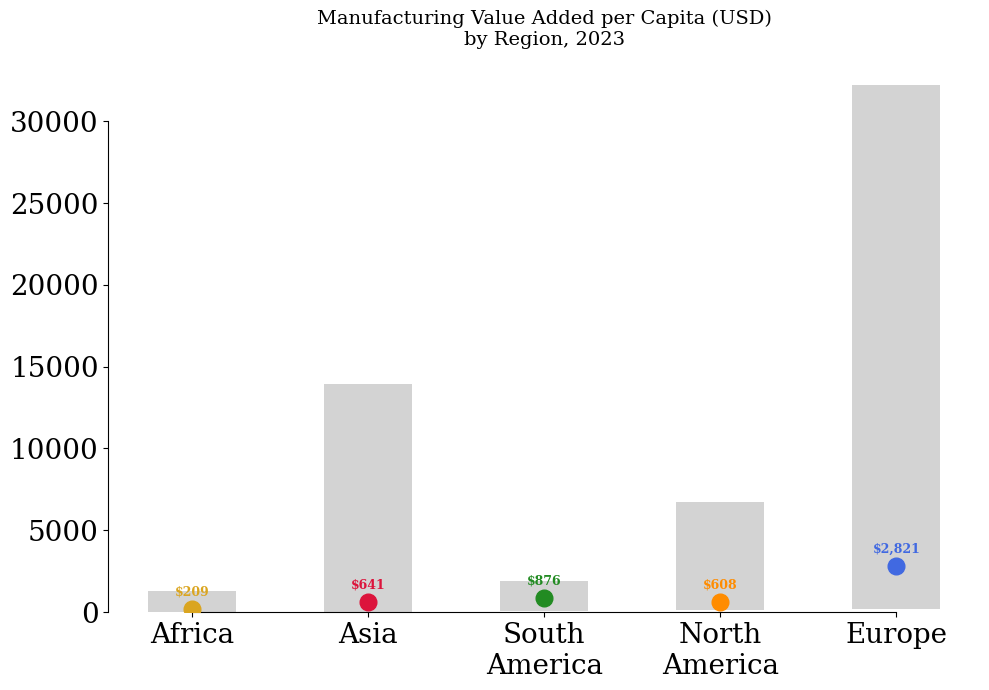

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

order = ['Africa', 'Asia', 'South America', 'North America', 'Europe']

region_colors = {
    'Africa': 'goldenrod',
    'Asia': 'crimson',
    'Europe': 'royalblue',
    'North America': 'darkorange',
    'South America': 'forestgreen'
}

for i, region in enumerate(order):
    subset = df_mva[df_mva['Region'] == region]['Value']
    
    # Gray bar from min to max (the range)
    ax.bar(x=i, 
           height=subset.max() - subset.min(), 
           bottom=subset.min(), 
           width=0.5, 
           color='lightgray', 
           edgecolor='none')
    
    # Colored dot for median
    ax.plot(i, subset.median(), 'o', 
            color=region_colors[region], 
            markersize=12, 
            zorder=5)

    # Text above median value dots
    offset = (df_mva['Value'].max() - df_mva['Value'].min()) * 0.02
    ax.text(i, subset.median() + offset, f'${subset.median():,.0f}',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold', color=region_colors[region])

ax.set_xticks(range(len(order)))
ax.set_xticklabels(order)
ax.set_xlabel("")
# Split two-word region names onto separate lines
ax.set_xticks(range(len(order)))
ax.set_xticklabels([r.replace(' ', '\n') for r in order])

ax.set_ylabel("")
ax.set_yticks(np.arange(0,35000,5000))

plt.title("Manufacturing Value Added per Capita (USD)\nby Region, 2023",
          fontsize=14, fontweight='light', pad=10)

sns.despine(fig, trim=True)
plt.tight_layout()
plt.show()

Task 1: Violin plot:

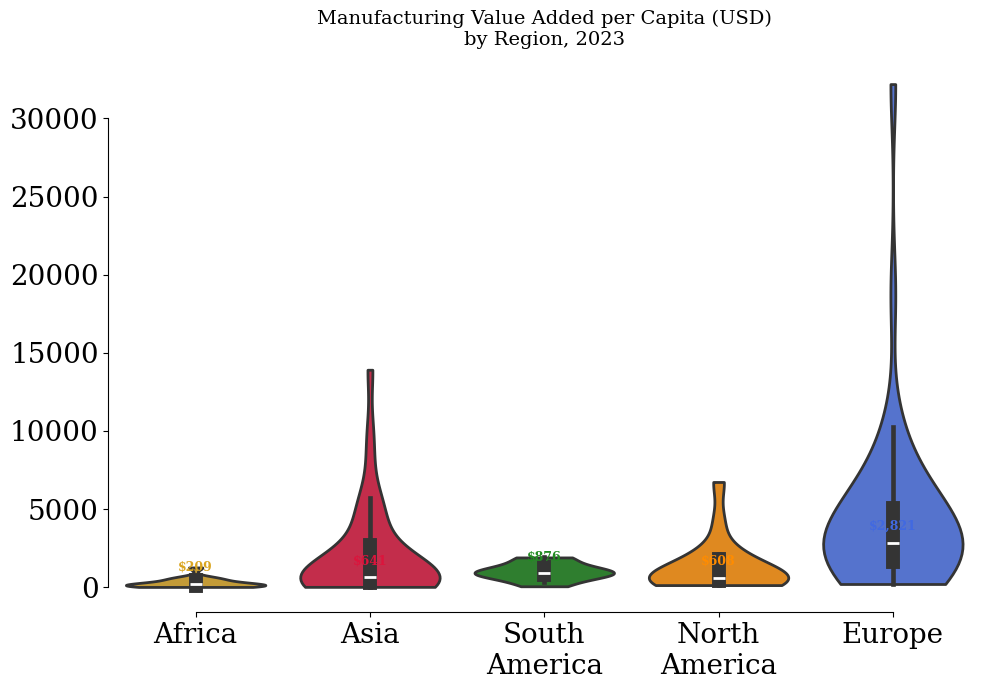

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

order = ['Africa', 'Asia', 'South America', 'North America', 'Europe']

region_colors = {
    'Africa': 'goldenrod',
    'Asia': 'crimson',
    'Europe': 'royalblue',
    'North America': 'darkorange',
    'South America': 'forestgreen'
}

sns.violinplot(
    data=df_mva,
    x='Region',
    y='Value',
    hue='Region',
    palette=region_colors,
    order=order,
    legend=False,
    linewidth=2,
    inner_kws=dict(box_width=10),
    cut=0  # Stops the violin from extending beyond the data range
)

# Median labels
medians = df_mva.groupby('Region')['Value'].median()
offset = (df_mva['Value'].max() - df_mva['Value'].min()) * 0.02
for i, region in enumerate(order):
    med = medians[region]
    ax.text(i, med + offset, f'${med:,.0f}',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold', color=region_colors[region])

ax.set_xticks(range(len(order)))
ax.set_xticklabels([r.replace(' ', '\n') for r in order])
ax.set_xlabel("")
ax.set_ylabel("")
#ax.set_yscale('log')

plt.title("Manufacturing Value Added per Capita (USD)\nby Region, 2023",
          fontsize=14, fontweight='light', pad=10)

sns.despine(fig, trim=True)
plt.tight_layout()
plt.show()

Task 1: Back to the original plot

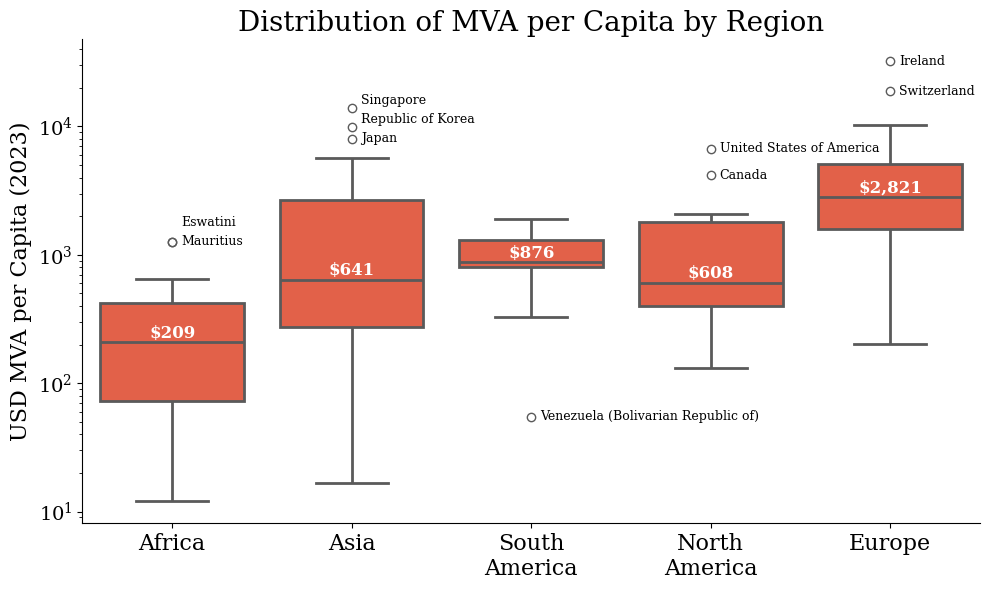

In [10]:
# Plot
region_colors = {
    'Africa': 'goldenrod',
    'Asia': 'crimson',
    'Europe': 'royalblue',
    'North America': 'darkorange',
    'South America': 'forestgreen'
}

region_colors = {
    'Africa': cc.glasbey_hv[1],
    'Asia': cc.glasbey_hv[1],
    'Europe': cc.glasbey_hv[1],
    'North America': cc.glasbey_hv[1],
    'South America': cc.glasbey_hv[1]
}

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

sns.boxplot(
    data=df_mva,
    x='Region',
    y='Value',
    hue='Region',
    palette=region_colors,
    legend=False,
    linewidth=2,
    order=['Africa', 'Asia', 'South America', 'North America', 'Europe']
)

ax.set_ylabel("USD MVA per Capita (2023)", fontsize=16)
ax.set_xlabel("")

# Split two-word region names onto separate lines
ax.set_xticks(range(len(order)))
ax.set_xticklabels([r.replace(' ', '\n') for r in order])
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=16)
#ax.tick_params(axis='x', length=0)

ax.set_yscale('log')
#ax.set_yticks([10, 100, 1000, 10000])
#ax.set_yticklabels(['$10', '$100', '$1,000', '$10,000'])

plt.title("Distribution of MVA per Capita by Region")
sns.despine(fig)
plt.tight_layout()
plt.savefig("../figures/boxplot-mva-regions.pdf", bbox_inches="tight", transparent=True)

# Identify and label outliers
order = ['Africa', 'Asia', 'South America', 'North America', 'Europe']

for i, region in enumerate(order):
    subset = df_mva[df_mva['Region'] == region]
    q1 = subset['Value'].quantile(0.25)
    q3 = subset['Value'].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr
    
    outliers = subset[(subset['Value'] > upper) | (subset['Value'] < lower)]
    outliers = outliers.sort_values('Value')
    
    # Collect y-positions and nudge if too close
    prev_y = None
    min_gap = 0.15  # minimum gap in log scale units
    
    for _, row in outliers.iterrows():
        y = np.log10(row['Value']) if row['Value'] > 0 else 0
        
        if prev_y is not None and abs(y - prev_y) < min_gap:
            y = prev_y + min_gap
        
        prev_y = y
        
        '''ax.text(i + 0.15, 10**y, f"{row['Country']}\n(${row['Value']:,.0f})",
                fontsize=8, fontweight='semibold', va='center', ha='left')'''
        ax.text(i + 0.05, 10**y, f"{row['Country']}",
                fontsize=9, fontweight='light', va='center', ha='left')

# Calculate and display medians
medians = df_mva.groupby('Region')['Value'].median()
order = ['Africa', 'Asia', 'South America', 'North America', 'Europe']

for i, region in enumerate(order):
    med = medians[region]
    ax.text(i, med * 1.01, f'${med:,.0f}',
            ha='center', va='bottom',
            fontsize=12, fontweight='bold', color='white')

plt.savefig("../figures/continents_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

Task 1: Visualization for South American nations:

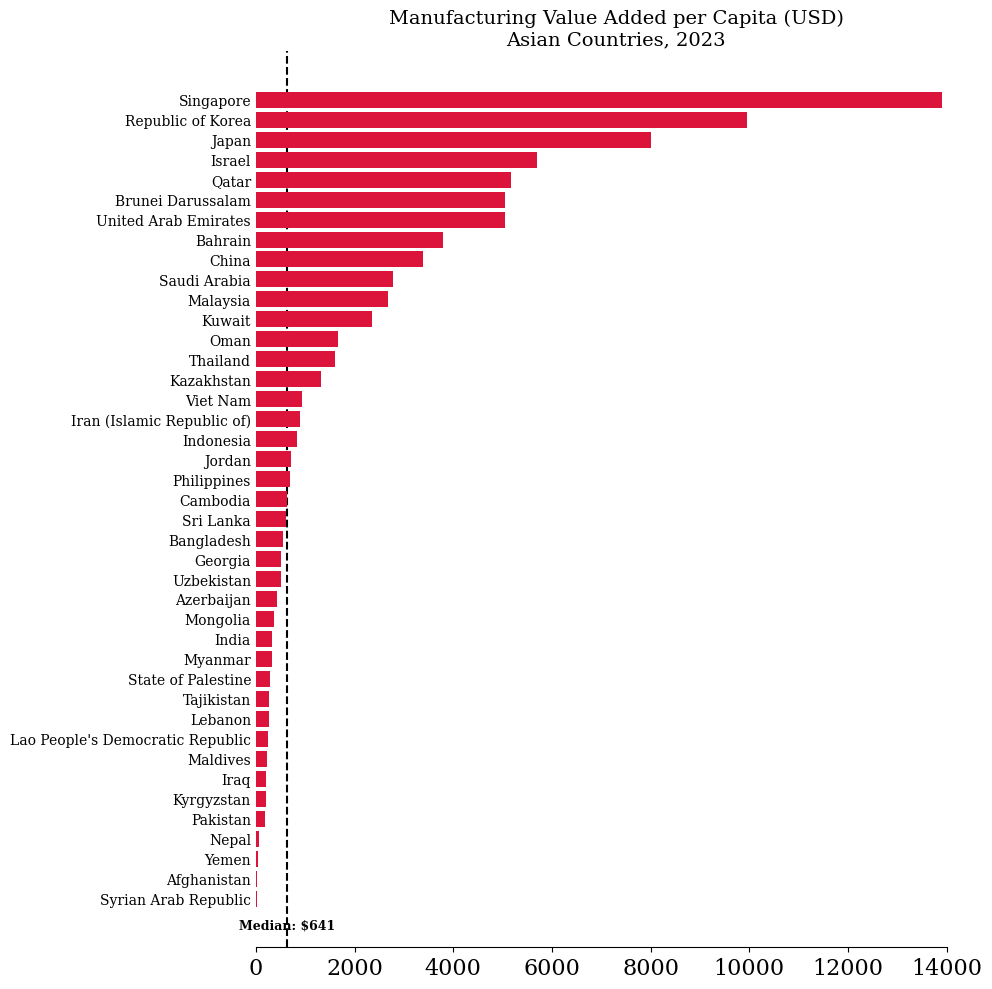

In [11]:
df_mva_asia = df_mva[df_mva['Region'] == 'Asia'].copy()

df_mva_asia_sorted = df_mva_asia.sort_values('Value', ascending=True)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

ax.barh(y=df_mva_asia_sorted['Country'], 
        width=df_mva_asia_sorted['Value'],
        color='crimson',
        edgecolor='none')

ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', length=0)
plt.title("Manufacturing Value Added per Capita (USD)\nAsian Countries, 2023",
          fontsize=14, fontweight='light', pad=5)

median_val = df_mva_asia['Value'].median()

ax.axvline(x=median_val, color='black', linestyle='--', linewidth=1.5, zorder=0)
ax.text(median_val, -1.5, f'Median: ${median_val:,.0f}', 
        ha='center', fontsize=9, fontweight='bold')

sns.despine(fig, trim=True)
sns.despine(fig, left=True, trim=True)
plt.tight_layout()
plt.savefig("../figures/asia_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

Task 1: Visualization for South American nations:

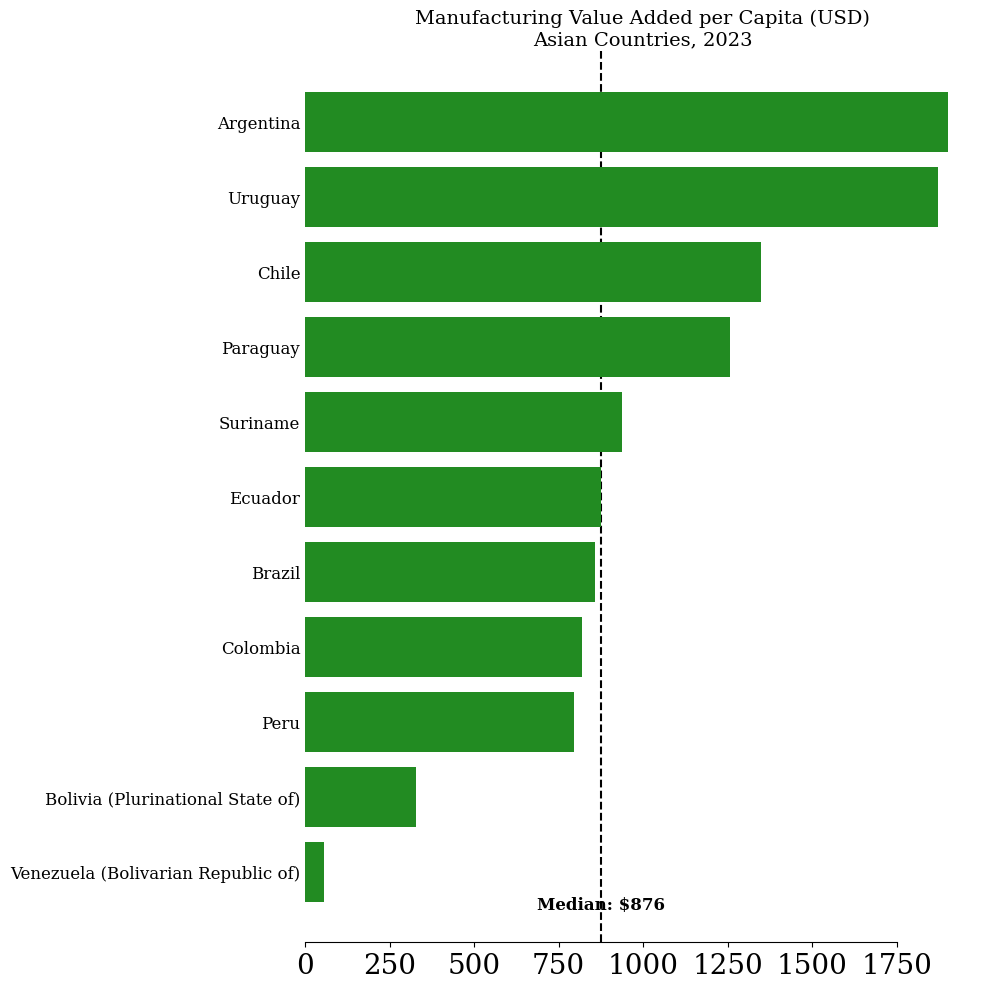

In [12]:
df_mva_samerica = df_mva[df_mva['Region'] == 'South America'].copy()

df_mva_samerica_sorted = df_mva_samerica.sort_values('Value', ascending=True)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

ax.barh(y=df_mva_samerica_sorted['Country'], 
        width=df_mva_samerica_sorted['Value'],
        color='forestgreen',
        edgecolor='none')

ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='y', length=0)
plt.title("Manufacturing Value Added per Capita (USD)\nAsian Countries, 2023",
          fontsize=14, fontweight='light', pad=5)

median_val = df_mva_samerica['Value'].median()

ax.axvline(x=median_val, color='black', linestyle='--', linewidth=1.5, zorder=0)
ax.text(median_val, -0.5, f'Median: ${median_val:,.0f}', 
        ha='center', fontsize=12, fontweight='bold')

sns.despine(fig, trim=True)
sns.despine(fig, left=True, trim=True)
plt.tight_layout()
plt.savefig("../figures/s_america_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

# Task 2: Visualizing Time Series

In [13]:
df = pd.read_csv("../data/data1long.csv")

Using the same continents as before, the idea is to create average values and then time series of these average values

In [14]:
# Assign regions to the full dataset
df['Region'] = df['Country'].apply(assign_region)

# Filter for your variable and drop unassigned countries
df_impact = df[(df['Variable'] == 'Impact of a country on world manufactures trade')].copy()
df_impact = df_impact.dropna(subset=['Region'])

# Calculate average per region per year
df_avg = df_impact.groupby(['Year', 'Region'])['Value'].mean().reset_index()

In [15]:
display(df_avg)

,Year,Region,Value
0,1990,Africa,0.000286
1,1990,Asia,0.005543
2,1990,Europe,0.014791
3,1990,North America,0.009651
4,1990,South America,0.001483
...,...,...,...
165,2023,Africa,0.000325
166,2023,Asia,0.008012
167,2023,Europe,0.008537
168,2023,North America,0.005542


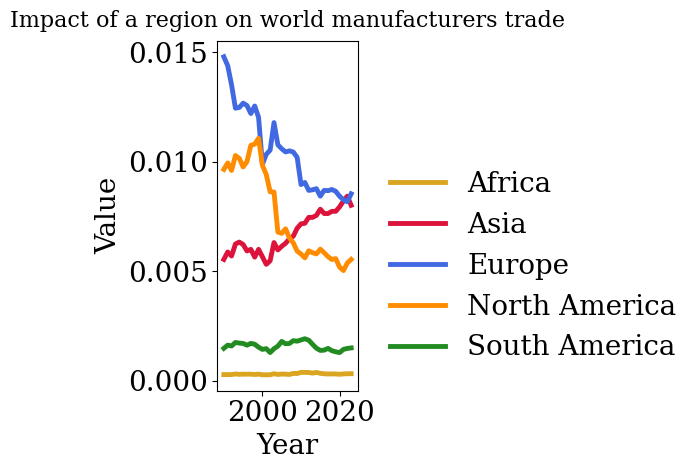

In [16]:
country_colors = {
    'Africa': 'goldenrod',
    'Asia': 'crimson',
    'Europe': 'royalblue',
    'North America': 'darkorange',
    'South America': 'forestgreen'
}

# Plotting the data
sns.lineplot(
    data=df_avg, 
    x='Year', 
    y='Value', 
    hue='Region',
    palette=country_colors,
    #marker='o',      # Dot for each year in the time series
    linewidth=3.5    # Line width
)

# Modifying axes to be simpler 
#ax.set_xticks(np.arange(1990,2023,10))
ax.set_xticks([1990, 2000, 2010, 2023])
ax.set_yticks(np.arange(0.00,0.35,0.1))
ax.set_xlabel("")
ax.set_ylabel("")

# Title split into two lines
plt.title("Impact of a region on world manufacturers trade", 
          fontsize=16, 
          fontweight='light', 
          pad=10)

# Customizing the layout
# plt.title("Competitive Industrial Performance Scores [0,1] through the years: Nordic Countries")
# plt.ylabel("CIP Score (Index Value [0,1])")
# plt.xlabel("Year")
# plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Moving the legend outside if it overlaps the data
plt.legend(bbox_to_anchor=(1.05, 0.7), loc='upper left')


# Clean finish, trim the axes and image spine
sns.despine(fig, trim=True) # Removes top and right spines
plt.tight_layout()




# Extend the X-axis limit to make room for the labels
ax.set_xlim(1988, 2026)

# Save the high-quality figure to your figures folder
plt.savefig("../figures/region_timeseries.png", dpi=300, bbox_inches='tight')

# Show the plot in the notebook
plt.show()

#THIS GRAPH IS WRONG; SHOULD BE A WEIGHTED AVERAGE

# Task 2: Visualizing Time Series **second try**

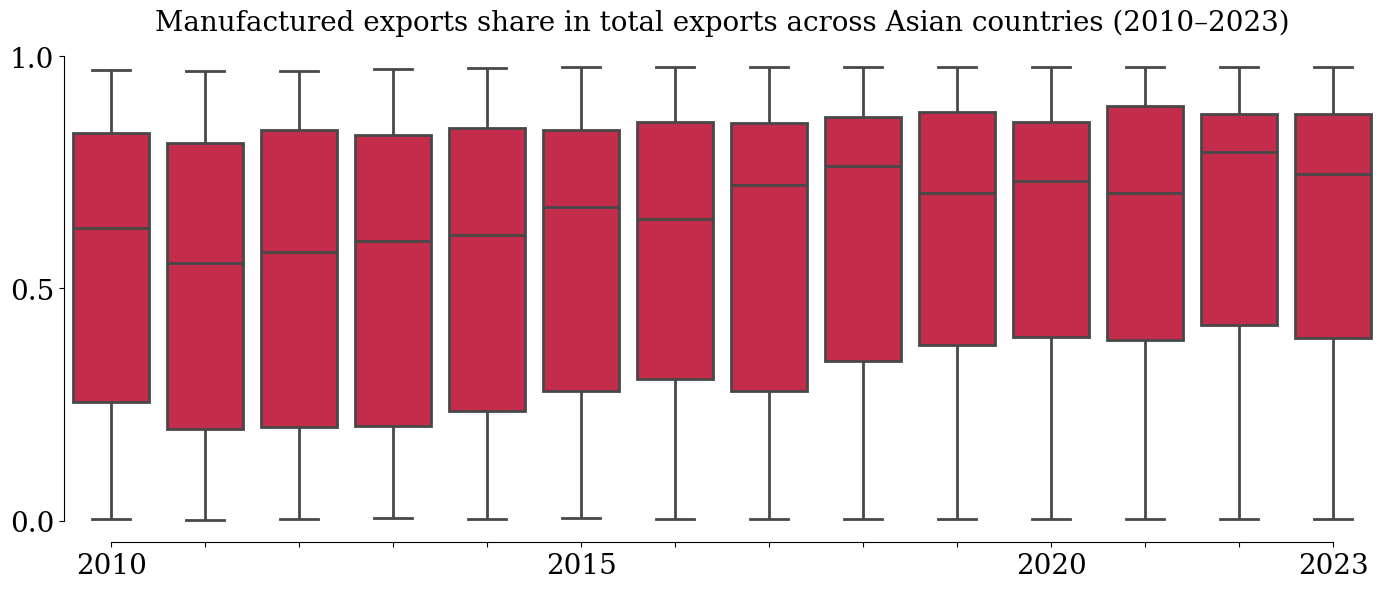

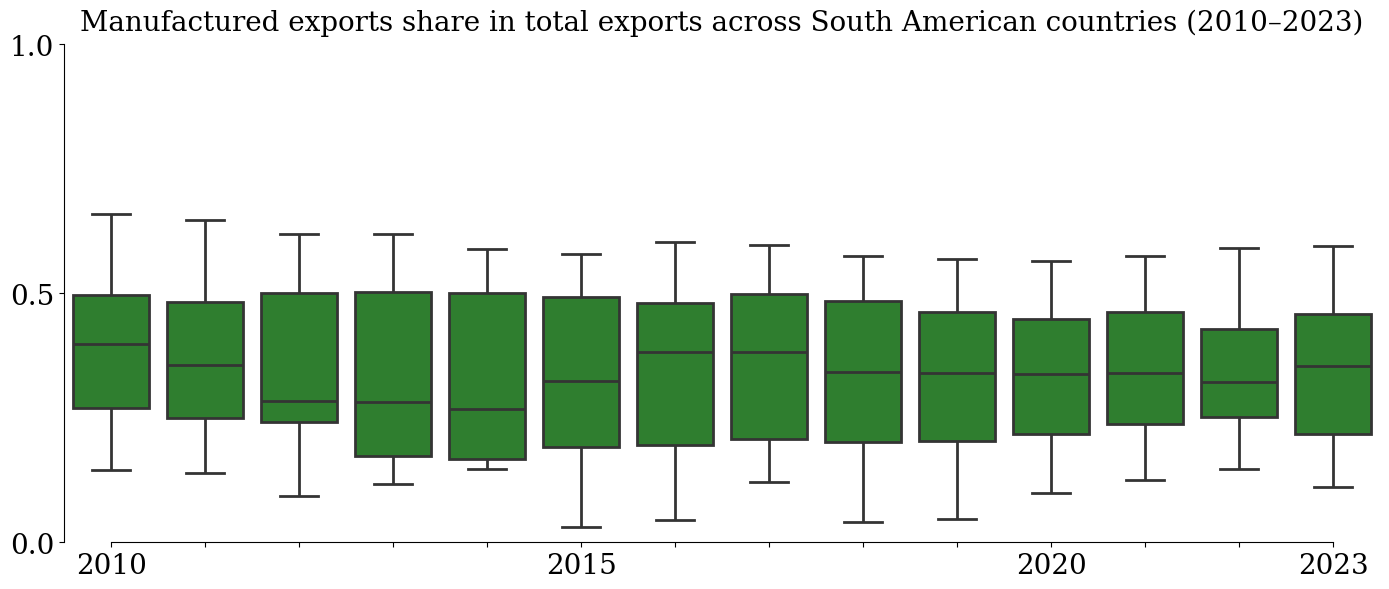

In [17]:
# Prepare temporal data
df = pd.read_csv("../data/data1.csv")
years = list(range(2010, 2024))
df_temporal = df[(df['Variable'] == 'Manufactured exports share in total exports') & 
                 (df['Year'].isin(years))].copy()
df_temporal['Region'] = df_temporal['Country'].apply(assign_region)

# --- Asia ---
df_asia_temp = df_temporal[df_temporal['Region'] == 'Asia']

fig, ax = plt.subplots(1, 1, figsize=(14, 6))

sns.boxplot(
    data=df_asia_temp,
    x='Year',
    y='Value',
    color='crimson',
    linewidth=2
)

#ax.set_yscale('log')
ax.set_yticks([0, 0.5, 1])

#tick marks for x-axis
years = sorted(df_temporal['Year'].unique())
ax.set_xticks(range(len(years)))
ax.set_xticklabels([str(y) if y in [2010, 2015, 2020, 2023] else '' for y in years])

#ax.set_yticklabels(['$10', '$100', '$1,000', '$10,000'])
ax.set_xlabel("")
ax.set_ylabel("")

plt.title("Manufactured exports share in total exports across Asian countries (2010–2023)",
          fontsize=20, fontweight='light', pad=10)

sns.despine(fig, trim=True)
plt.tight_layout()
plt.savefig("../figures/boxplot-asia-temporal.pdf", bbox_inches="tight", transparent=True)
plt.savefig("../figures/boxplot-asia-temporal.png", dpi=300, bbox_inches='tight')
plt.show()

# --- South America ---
df_sa_temp = df_temporal[df_temporal['Region'] == 'South America']

fig, ax = plt.subplots(1, 1, figsize=(14, 6))

sns.boxplot(
    data=df_sa_temp,
    x='Year',
    y='Value',
    color='forestgreen',
    linewidth=2
)

#ax.set_yscale('log')
ax.set_yticks([0, 0.5, 1])
#ax.set_xticks([2010, 2015, 2020, 2023])

#tick marks for x-axis
years = sorted(df_temporal['Year'].unique())
ax.set_xticks(range(len(years)))
ax.set_xticklabels([str(y) if y in [2010, 2015, 2020, 2023] else '' for y in years])

#ax.set_yticklabels(['$100', '$1,000', '$10,000'])
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis='y', labelsize=20)
ax.tick_params(axis='x', labelsize=20)


plt.title("Manufactured exports share in total exports across South American countries (2010–2023)",
          fontsize=20, fontweight='light', pad=10)

sns.despine(fig, trim=True)
plt.tight_layout()
plt.savefig("../figures/boxplot-sa-temporal.pdf", bbox_inches="tight", transparent=True)
plt.savefig("../figures/boxplot-sa-temporal.png", dpi=300, bbox_inches='tight')
plt.show()

# **Task 3:** Visualizing high-dimensional data 

In [18]:
# define task 3 comparison group 
group = ['Germany', 'China', 'Ireland', 'United States', 
                 'Switzerland', 'Finland', 'Sweden', 'India', 'Brazil', 'Mexico']

**Variables to observe:**
- Manufactured exports per capita
- Manufacturing value added share in total GDP
- Manufacturing value added per capita
- Manufactured exports share in total exports
- Medium- and high-tech manufactured exports share in total manufactured exports

**Other options:**
- MVA per capita index
- Share of medium and high-tech activities in manufacturing export index
- Share of medium and high-tech activities in total MVA index
- Industrialization intensity index
- Industrial export quality index
- Manufactured exports per capita index

# First visualization (Parallel Coordinates)

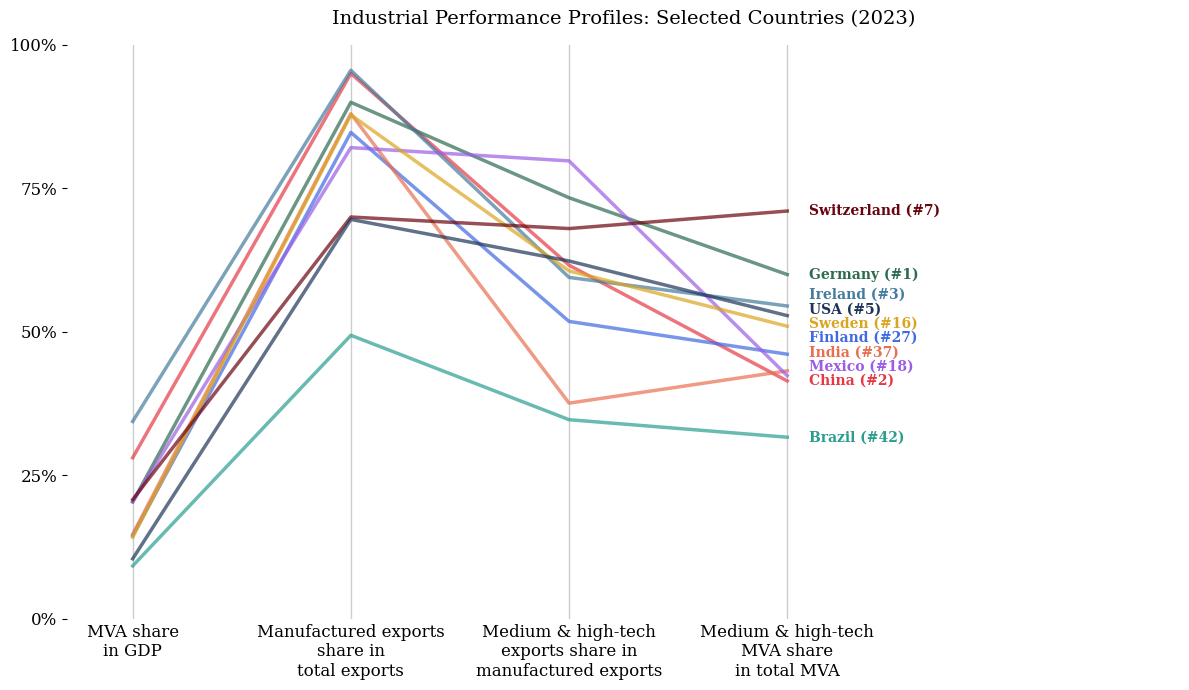

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path
import matplotlib.patches as patches

# Countries and variables
group = ['Germany', 'China', 'Ireland', 'United States of America', 
         'Switzerland', 'Finland', 'Sweden', 'India', 'Brazil', 'Mexico']

variables = [
    'Manufacturing value added share in total GDP',
    'Manufactured exports share in total exports',
    'Medium- and high-tech manufactured exports share in total manufactured exports',
    'Medium- and high-tech MVA share in total MVA'
]

short_labels = [
    'MVA share\nin GDP',
    'Manufactured exports\nshare in\ntotal exports',
    'Medium & high-tech\nexports share in\nmanufactured exports',
    'Medium & high-tech\nMVA share\nin total MVA'
]

# Filter and pivot
subset = df[(df['Year'] == 2023) & (df['Country'].isin(group)) & (df['Variable'].isin(variables))]
wide = subset.pivot(index='Country', columns='Variable', values='Value')[variables]

# Get CIP ranks
ranks_df = df[(df['Year'] == 2023) & (df['Country'].isin(group)) & (df['Variable'] == 'CIP rank')]
cip_ranks = dict(zip(ranks_df['Country'], ranks_df['Value'].astype(int)))

country_colors = {
    'Germany': '#2d6a4f',
    'China': '#e63946',
    'Ireland': '#457b9d',
    'United States of America': '#1d3557',
    'Switzerland': '#6a040f',
    'Finland': '#4169E1',
    'Sweden': '#DAA520',
    'India': '#e76f51',
    'Brazil': '#2a9d8f',
    'Mexico': '#9b5de5'
}

display_names = {
    'United States of America': 'USA',
    'Germany': 'Germany',
    'China': 'China',
    'Ireland': 'Ireland',
    'Switzerland': 'Switzerland',
    'Finland': 'Finland',
    'Sweden': 'Sweden',
    'India': 'India',
    'Brazil': 'Brazil',
    'Mexico': 'Mexico'
}

fig, ax = plt.subplots(1, 1, figsize=(12, 7))

x_positions = np.arange(len(variables))

for i in range(len(variables)):
    ax.axvline(x=i, color='#cccccc', linewidth=1, zorder=0)

# Collect end positions for nudging
end_values = {}
for country in wide.index:
    end_values[country] = wide.loc[country].values[-1]

# Sort by end value to nudge overlapping labels
sorted_countries = sorted(end_values.keys(), key=lambda c: end_values[c])
min_gap = 0.025  # minimum vertical gap between labels

# Calculate nudged positions
label_positions = {}
prev_y = None
for country in sorted_countries:
    y = end_values[country]
    if prev_y is not None and y - prev_y < min_gap:
        y = prev_y + min_gap
    label_positions[country] = y
    prev_y = y

# Draw lines and labels
for country in wide.index:
    values = wide.loc[country].values
    ax.plot(x_positions, values,
            color=country_colors[country],
            linewidth=2.5,
            alpha=0.7,
            zorder=3)

    label = f"{display_names[country]} (#{cip_ranks[country]})"
    ax.text(len(variables) - 1 + 0.1, label_positions[country],
            label,
            color=country_colors[country],
            fontsize=10, fontweight='bold',
            va='center', ha='left')

ax.set_xticks(x_positions)
ax.set_xticklabels(short_labels, fontsize=8, ha='center')

ax.set_ylim(0, 1)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'], fontsize=12)
ax.tick_params(axis='x', labelsize=12)

ax.set_xlim(-0.3, len(variables) - 1 + 1.8)
ax.set_ylabel('')
ax.set_xlabel('')

plt.title("Industrial Performance Profiles: Selected Countries (2023)",
          fontsize=14, fontweight='light', pad=15, ha='center')

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(axis='x', length=0)

plt.tight_layout()
plt.savefig("../figures/parallel-coordinates.png", dpi=300, bbox_inches='tight')
plt.show()

# Second visualization: Heatmap, South America

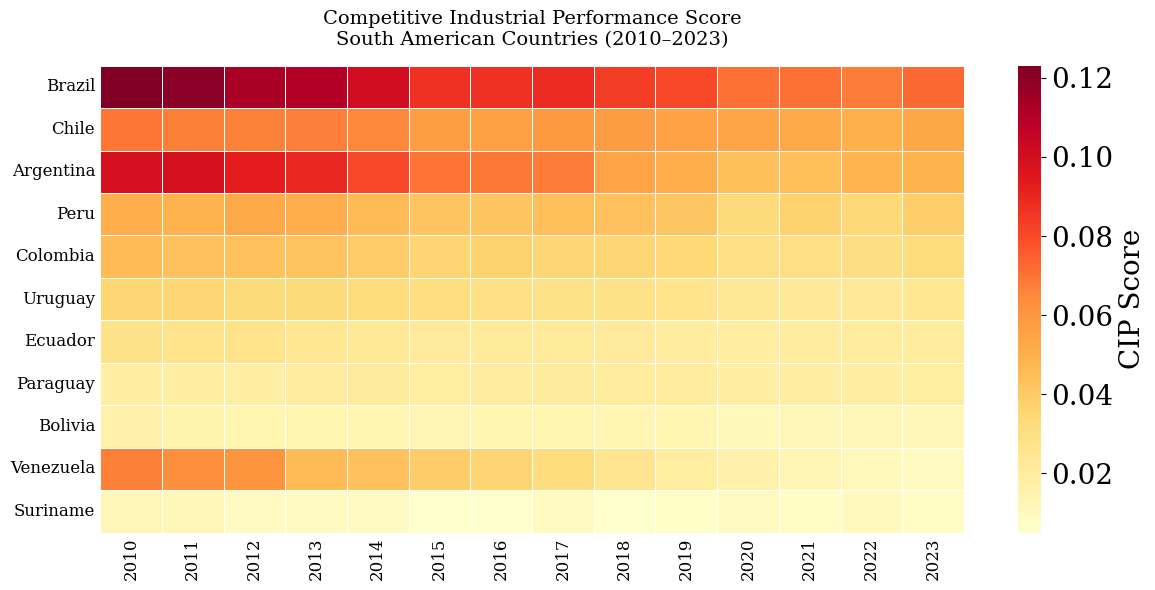

In [20]:
south_america = ['Argentina', 'Bolivia (Plurinational State of)', 'Brazil', 'Chile', 
                 'Colombia', 'Ecuador', 'Paraguay', 'Peru', 'Suriname', 'Uruguay', 
                 'Venezuela (Bolivarian Republic of)']

# Filter and pivot
df_sa_cip = df[(df['Country'].isin(south_america)) & (df['Variable'] == 'CIP score')]
df_pivot = df_sa_cip.pivot(index='Country', columns='Year', values='Value')

# Sort by 2023 CIP score descending so strongest performers are at top
df_pivot = df_pivot.sort_values(2023, ascending=False)

# Shorter display names
display_names = {
    'Bolivia (Plurinational State of)': 'Bolivia',
    'Venezuela (Bolivarian Republic of)': 'Venezuela'
}
df_pivot.index = [display_names.get(c, c) for c in df_pivot.index]

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

sns.heatmap(df_pivot, 
            xticklabels=1, 
            yticklabels=1, 
            cmap='YlOrRd',
            linewidths=0.5,
            linecolor='white',
            fmt='.3f',
            cbar_kws={'label': 'CIP Score'})

ax.tick_params(axis='y', length=0, labelsize=12)
ax.tick_params(axis='x', length=0, labelsize=12)
ax.set_ylabel('')
ax.set_xlabel('')

plt.title("Competitive Industrial Performance Score\nSouth American Countries (2010–2023)",
          fontsize=14, fontweight='light', pad=15)

plt.tight_layout()
plt.savefig("../figures/heatmap-cip-southamerica.png", dpi=300, bbox_inches='tight')
plt.show()

# Heatmap, Selected Countries

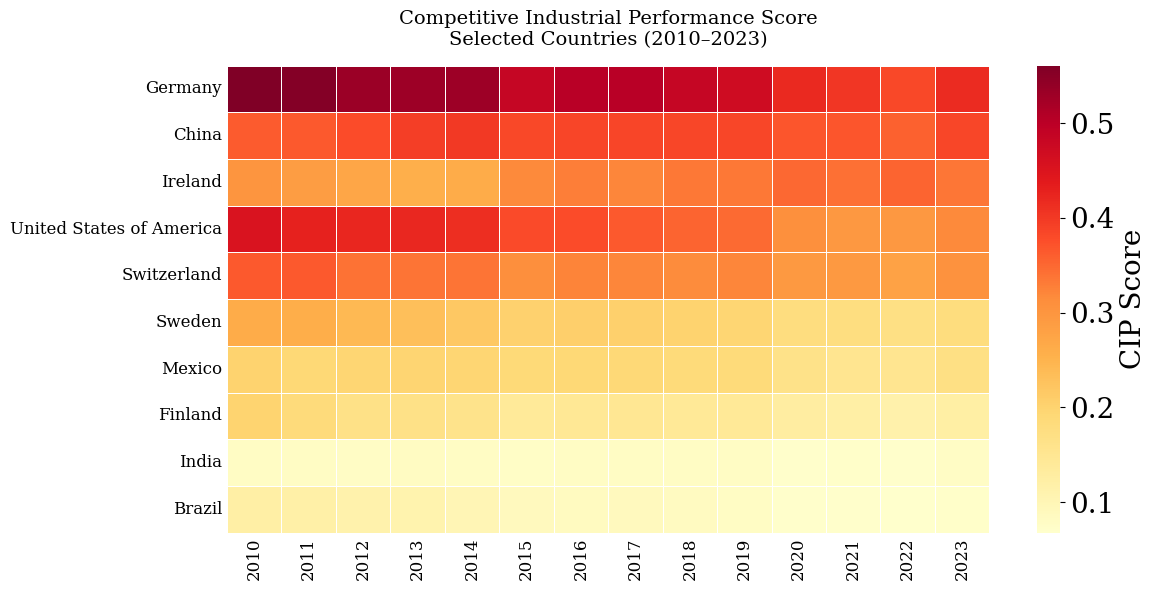

In [21]:
group = ['Germany', 'China', 'Ireland', 'United States of America', 
         'Switzerland', 'Finland', 'Sweden', 'India', 'Brazil', 'Mexico']

# Filter and pivot
df_sa_cip = df[(df['Country'].isin(group)) & (df['Variable'] == 'CIP score')]
df_pivot = df_sa_cip.pivot(index='Country', columns='Year', values='Value')

# Sort by 2023 CIP score descending so strongest performers are at top
df_pivot = df_pivot.sort_values(2023, ascending=False)

df_pivot.index = [display_names.get(c, c) for c in df_pivot.index]

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

sns.heatmap(df_pivot, 
            xticklabels=1, 
            yticklabels=1, 
            cmap='YlOrRd',
            linewidths=0.5,
            linecolor='white',
            fmt='.3f',
            cbar_kws={'label': 'CIP Score'})

ax.tick_params(axis='y', length=0, labelsize=12)
ax.tick_params(axis='x', length=0, labelsize=12)
ax.set_ylabel('')
ax.set_xlabel('')

plt.title("Competitive Industrial Performance Score\nSelected Countries (2010–2023)",
          fontsize=14, fontweight='light', pad=15)

plt.tight_layout()
plt.savefig("../figures/heatmap-cip-selected.png", dpi=300, bbox_inches='tight')
plt.show()

# Heatmap, South America + Germany

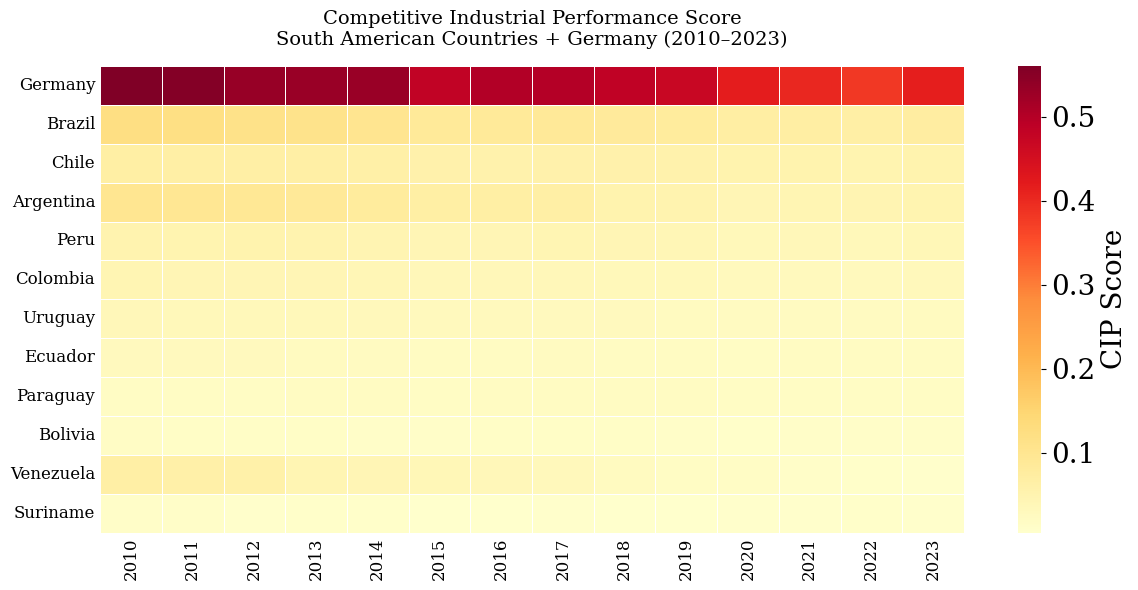

In [22]:
south_america = ['Germany', 'Argentina', 'Bolivia (Plurinational State of)', 'Brazil', 'Chile', 
                 'Colombia', 'Ecuador', 'Paraguay', 'Peru', 'Suriname', 'Uruguay', 
                 'Venezuela (Bolivarian Republic of)']

# Filter and pivot
df_sa_cip = df[(df['Country'].isin(south_america)) & (df['Variable'] == 'CIP score')]
df_pivot = df_sa_cip.pivot(index='Country', columns='Year', values='Value')

# Sort by 2023 CIP score descending so strongest performers are at top
df_pivot = df_pivot.sort_values(2023, ascending=False)

# Shorter display names
display_names = {
    'Bolivia (Plurinational State of)': 'Bolivia',
    'Venezuela (Bolivarian Republic of)': 'Venezuela'
}
df_pivot.index = [display_names.get(c, c) for c in df_pivot.index]

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

sns.heatmap(df_pivot, 
            xticklabels=1, 
            yticklabels=1, 
            cmap='YlOrRd',
            linewidths=0.5,
            linecolor='white',
            fmt='.3f',
            cbar_kws={'label': 'CIP Score'})

ax.tick_params(axis='y', length=0, labelsize=12)
ax.tick_params(axis='x', length=0, labelsize=12)
ax.set_ylabel('')
ax.set_xlabel('')

plt.title("Competitive Industrial Performance Score\nSouth American Countries + Germany (2010–2023)",
          fontsize=14, fontweight='light', pad=15)

plt.tight_layout()
plt.savefig("../figures/heatmap-cip-south-and-ger.png", dpi=300, bbox_inches='tight')
plt.show()

# Third visualization, scatter plot matrix

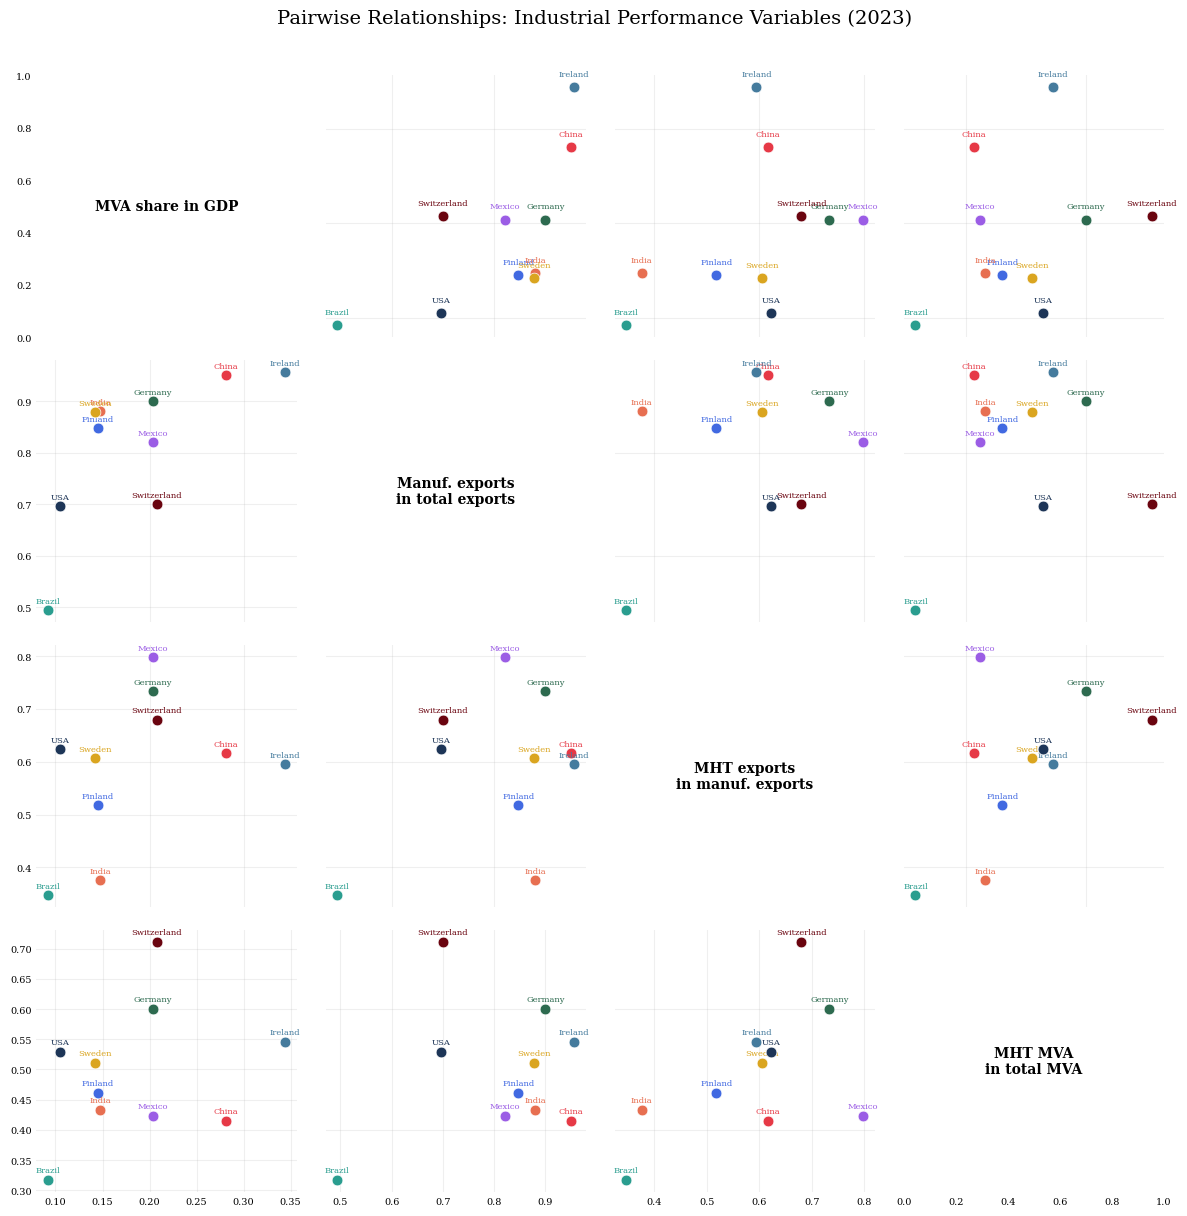

In [23]:
group = ['Germany', 'China', 'Ireland', 'United States of America', 
         'Switzerland', 'Finland', 'Sweden', 'India', 'Brazil', 'Mexico']

variables = [
    'Manufacturing value added share in total GDP',
    'Manufactured exports share in total exports',
    'Medium- and high-tech manufactured exports share in total manufactured exports',
    'Medium- and high-tech MVA share in total MVA'
]

short_names = {
    'Manufacturing value added share in total GDP': 'MVA share in GDP',
    'Manufactured exports share in total exports': 'Manuf. exports\nin total exports',
    'Medium- and high-tech manufactured exports share in total manufactured exports': 'MHT exports\nin manuf. exports',
    'Medium- and high-tech MVA share in total MVA': 'MHT MVA\nin total MVA'
}

# Filter, pivot, rename
subset = df[(df['Year'] == 2023) & (df['Country'].isin(group)) & (df['Variable'].isin(variables))]
wide = subset.pivot(index='Country', columns='Variable', values='Value')[variables]
wide.columns = [short_names[v] for v in wide.columns]
wide = wide.reset_index()

# Shorter display names
wide['Country'] = wide['Country'].replace({'United States of America': 'USA'})

# Colors
country_colors = {
    'Germany': '#2d6a4f',
    'China': '#e63946',
    'Ireland': '#457b9d',
    'USA': '#1d3557',
    'Switzerland': '#6a040f',
    'Finland': '#4169E1',
    'Sweden': '#DAA520',
    'India': '#e76f51',
    'Brazil': '#2a9d8f',
    'Mexico': '#9b5de5'
}

plot_vars = list(short_names.values())

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for i, var_y in enumerate(plot_vars):
    for j, var_x in enumerate(plot_vars):
        ax = axes[i][j]
        
        if i == j:
            # Diagonal: variable name
            ax.text(0.5, 0.5, var_y, ha='center', va='center',
                    fontsize=10, fontweight='bold', transform=ax.transAxes)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
        else:
            # Scatter plot
            for _, row in wide.iterrows():
                ax.scatter(row[var_x], row[var_y],
                          color=country_colors[row['Country']],
                          s=60, zorder=3, edgecolors='white', linewidth=0.5)
                
                # Label each point
                ax.text(row[var_x], row[var_y] + 0.01, row['Country'],
                        fontsize=6, ha='center', va='bottom',
                        color=country_colors[row['Country']])
        
        # Only show axis labels on edges
        if i == 3:
            ax.tick_params(axis='x', labelsize=7)
        else:
            ax.set_xticklabels([])
        
        if j == 0:
            ax.tick_params(axis='y', labelsize=7)
        else:
            ax.set_yticklabels([])
        
        ax.tick_params(length=0)
        
        # Light grid
        if i != j:
            ax.grid(True, alpha=0.2)
        
        # Remove spines
        for spine in ax.spines.values():
            spine.set_visible(False)

plt.suptitle("Pairwise Relationships: Industrial Performance Variables (2023)",
             fontsize=14, fontweight='light', y=1.01)

plt.tight_layout()
plt.savefig("../figures/scatter-matrix.pdf", bbox_inches="tight", transparent=True)
plt.show()

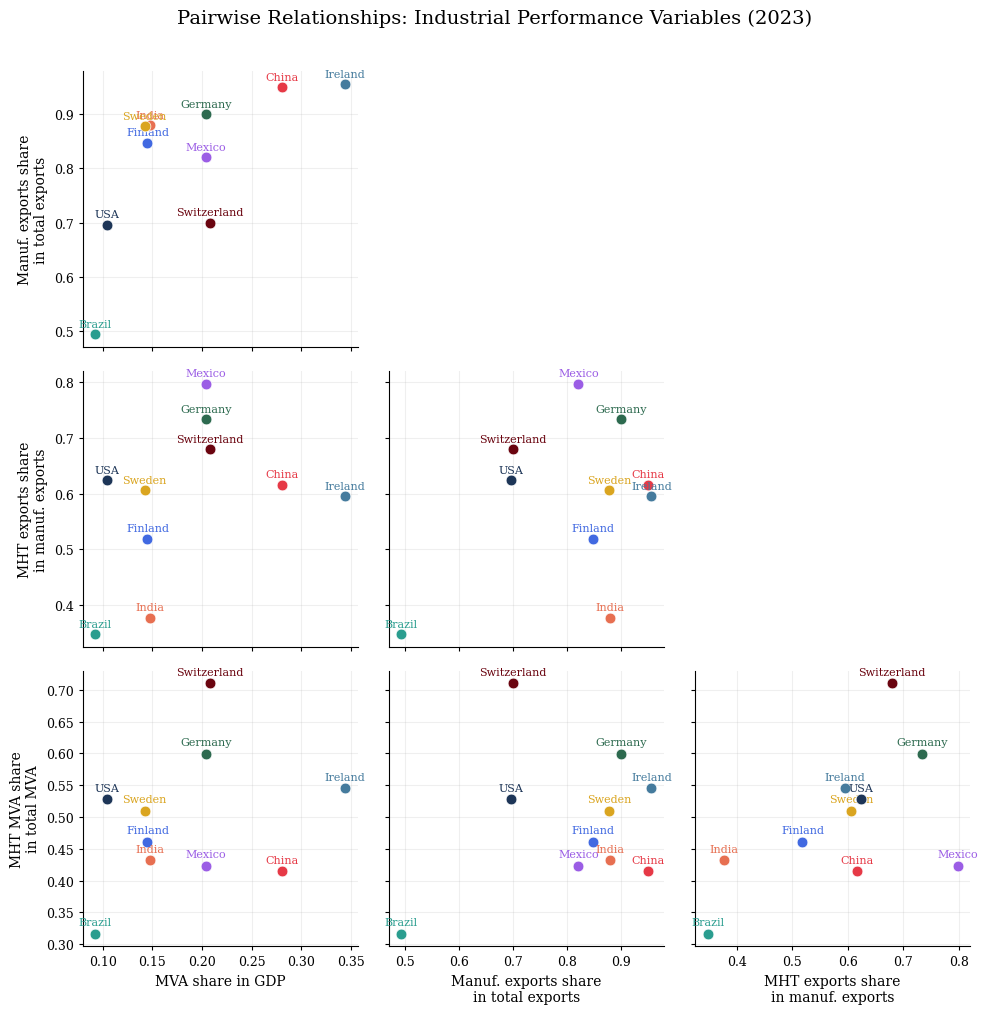

In [24]:
group = ['Germany', 'China', 'Ireland', 'United States of America', 
         'Switzerland', 'Finland', 'Sweden', 'India', 'Brazil', 'Mexico']

variables = [
    'Manufacturing value added share in total GDP',
    'Manufactured exports share in total exports',
    'Medium- and high-tech manufactured exports share in total manufactured exports',
    'Medium- and high-tech MVA share in total MVA'
]

short_names = {
    'Manufacturing value added share in total GDP': 'MVA share in GDP',
    'Manufactured exports share in total exports': 'Manuf. exports share\nin total exports',
    'Medium- and high-tech manufactured exports share in total manufactured exports': 'MHT exports share\nin manuf. exports',
    'Medium- and high-tech MVA share in total MVA': 'MHT MVA share\nin total MVA'
}

subset = df[(df['Year'] == 2023) & (df['Country'].isin(group)) & (df['Variable'].isin(variables))]
wide = subset.pivot(index='Country', columns='Variable', values='Value')[variables]
wide.columns = [short_names[v] for v in wide.columns]
wide = wide.reset_index()
wide['Country'] = wide['Country'].replace({'United States of America': 'USA'})

country_colors = {
    'Germany': '#2d6a4f',
    'China': '#e63946',
    'Ireland': '#457b9d',
    'USA': '#1d3557',
    'Switzerland': '#6a040f',
    'Finland': '#4169E1',
    'Sweden': '#DAA520',
    'India': '#e76f51',
    'Brazil': '#2a9d8f',
    'Mexico': '#9b5de5'
}

plot_vars = list(short_names.values())
n = len(plot_vars)

fig, axes = plt.subplots(n - 1, n - 1, figsize=(10, 10))

for i in range(n - 1):       # rows (y-axis variables, starting from second variable)
    for j in range(n - 1):   # columns (x-axis variables)
        ax = axes[i][j]
        
        # Only draw lower triangle: column index must be less than row index + 1
        if j <= i:
            var_x = plot_vars[j]
            var_y = plot_vars[i + 1]
            
            for _, row in wide.iterrows():
                ax.scatter(row[var_x], row[var_y],
                          color=country_colors[row['Country']],
                          s=60, zorder=3, edgecolors='white', linewidth=0.5)
                
                ax.text(row[var_x], row[var_y] + 0.01, row['Country'],
                        fontsize=8, ha='center', va='bottom',
                        color=country_colors[row['Country']])
            
            ax.grid(True, alpha=0.2)
            
            # Y-axis label only on leftmost column
            if j == 0:
                ax.set_ylabel(var_y, fontsize=10)
                ax.tick_params(axis='y', labelsize=7)
            else:
                ax.set_yticklabels([])
            
            # X-axis label only on bottom row
            if i == n - 2:
                ax.set_xlabel(var_x, fontsize=10)
                ax.tick_params(axis='x', labelsize=7)
            else:
                ax.set_xticklabels([])
        else:
            # Hide upper triangle cells
            ax.set_visible(False)
        
        ax.tick_params(length=0)
        #for spine in ax.spines.values():
            #spine.set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        #ax.tick_params(length=4, width=1, color='#999999')
        ax.tick_params(axis='y', length=3, labelsize=9)
        ax.tick_params(axis='x', length=3, labelsize=9)

plt.suptitle("Pairwise Relationships: Industrial Performance Variables (2023)",
             fontsize=14, fontweight='light', y=1.01)

plt.tight_layout()
plt.savefig("../figures/pairwise.png", dpi=300, bbox_inches='tight')
plt.show()

# Visualization: Pairwise scatters, continent comparison

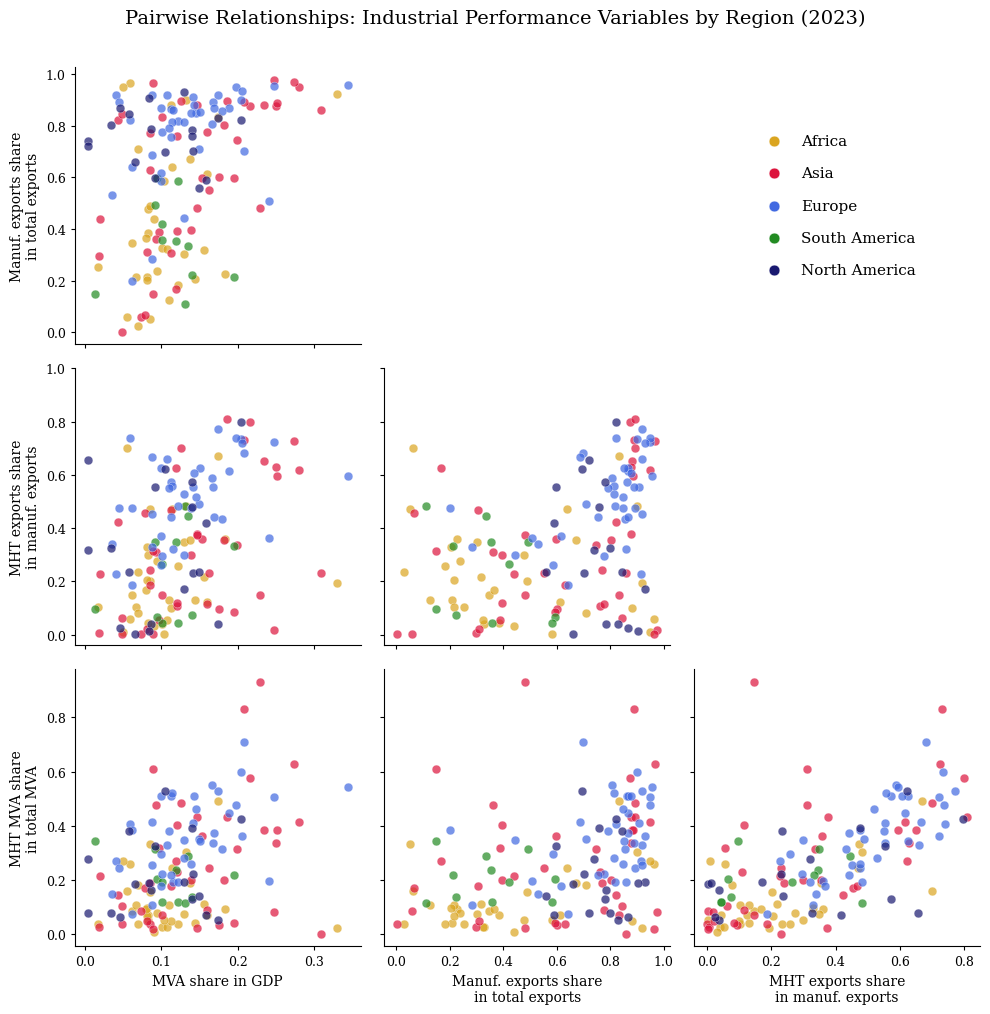

In [ ]:
# Region mappings (same as before)
south_america = ['Argentina', 'Bolivia (Plurinational State of)', 'Brazil', 'Chile', 
                 'Colombia', 'Ecuador', 'Paraguay', 'Peru', 'Suriname', 'Uruguay', 
                 'Venezuela (Bolivarian Republic of)']

north_america = ['Bahamas', 'Barbados', 'Belize', 'Bermuda', 'Canada', 'Costa Rica', 
                 'Cuba', 'El Salvador', 'Guatemala', 'Haiti', 'Honduras', 'Jamaica', 
                 'Mexico', 'Nicaragua', 'Panama', 'Saint Lucia', 
                 'Trinidad and Tobago', 'United States of America']

europe = ['Albania', 'Austria', 'Belarus', 'Belgium', 'Bosnia and Herzegovina', 
          'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Estonia', 
          'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland', 
          'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Montenegro', 
          'Netherlands (Kingdom of the)', 'North Macedonia', 'Norway', 'Poland', 
          'Portugal', 'Republic of Moldova', 'Romania', 'Russian Federation', 'Serbia', 
          'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Türkiye', 
          'Ukraine', 'United Kingdom']

asia = ['Afghanistan', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Brunei Darussalam', 
        'Cambodia', 'China', 'Georgia', 'India', 'Indonesia', 
        'Iran (Islamic Republic of)', 'Iraq', 'Israel', 'Japan', 'Jordan', 
        'Kazakhstan', 'Kuwait', 'Kyrgyzstan', "Lao People's Democratic Republic", 
        'Lebanon', 'Malaysia', 'Maldives', 'Mongolia', 'Myanmar', 'Nepal', 'Oman', 
        'Pakistan', 'Philippines', 'Qatar', 'Republic of Korea', 'Saudi Arabia', 
        'Singapore', 'Sri Lanka', 'State of Palestine', 'Syrian Arab Republic', 
        'Tajikistan', 'Thailand', 'United Arab Emirates', 'Uzbekistan', 'Viet Nam', 
        'Yemen']

africa = ['Algeria', 'Angola', 'Botswana', 'Burundi', 'Cabo Verde', 'Cameroon', 
          'Central African Republic', 'Congo', "Côte d'Ivoire", 'Egypt', 'Eritrea', 
          'Eswatini', 'Ethiopia', 'Gabon', 'Gambia', 'Ghana', 'Kenya', 
          'Madagascar', 'Malawi', 'Mauritius', 'Morocco', 'Mozambique', 'Namibia', 
          'Niger', 'Nigeria', 'Rwanda', 'Senegal', 'South Africa', 'Tunisia', 
          'Uganda', 'United Republic of Tanzania', 'Zambia', 'Zimbabwe']

def assign_region(country):
    if country in south_america:
        return 'South America'
    elif country in europe:
        return 'Europe'
    elif country in asia:
        return 'Asia'
    elif country in africa:
        return 'Africa'
    elif country in north_america:
        return 'North America'
    return None

variables = [
    'Manufacturing value added share in total GDP',
    'Manufactured exports share in total exports',
    'Medium- and high-tech manufactured exports share in total manufactured exports',
    'Medium- and high-tech MVA share in total MVA'
]

short_names = {
    'Manufacturing value added share in total GDP': 'MVA share in GDP',
    'Manufactured exports share in total exports': 'Manuf. exports share\nin total exports',
    'Medium- and high-tech manufactured exports share in total manufactured exports': 'MHT exports share\nin manuf. exports',
    'Medium- and high-tech MVA share in total MVA': 'MHT MVA share\nin total MVA'
}

subset = df[(df['Year'] == 2023) & (df['Variable'].isin(variables))]
wide = subset.pivot(index='Country', columns='Variable', values='Value')[variables].dropna()
wide.columns = [short_names[v] for v in wide.columns]
wide = wide.reset_index()
wide['Region'] = wide['Country'].apply(assign_region)
wide = wide.dropna(subset=['Region'])

region_colors = {
    'Africa': 'goldenrod',
    'Asia': 'crimson',
    'Europe': 'royalblue',
    'South America': 'forestgreen',
    'North America': 'midnightblue'
}

plot_vars = list(short_names.values())
n = len(plot_vars)

fig, axes = plt.subplots(n - 1, n - 1, figsize=(10, 10))

for i in range(n - 1):
    for j in range(n - 1):
        ax = axes[i][j]
        
        if j <= i:
            var_x = plot_vars[j]
            var_y = plot_vars[i + 1]
            
            for region in ['Africa', 'Asia', 'South America', 'Europe', 'North America']:
                region_data = wide[wide['Region'] == region]
                ax.scatter(region_data[var_x], region_data[var_y],
                          color=region_colors[region],
                          s=40, zorder=3, 
                          edgecolors='white', linewidth=0.3,
                          alpha=0.7,
                          label=region if i == 0 and j == 0 else None)
            
            #ax.grid(True, alpha=0.2)
            
            if j == 0:
                ax.set_ylabel(var_y, fontsize=10)
                ax.tick_params(axis='y', labelsize=9)
            else:
                ax.set_yticklabels([])
            
            if i == n - 2:
                ax.set_xlabel(var_x, fontsize=10)
                ax.tick_params(axis='x', labelsize=9)
            else:
                ax.set_xticklabels([])
        else:
            ax.set_visible(False)
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='y', length=3, labelsize=9)
        ax.tick_params(axis='x', length=3, labelsize=9)
    
        if var_y == 'MHT exports share\nin manuf. exports':
            ax.set_yticks(np.arange(0, 1.1, 0.2))

# Add legend in the empty upper-right area
axes[0][2].set_visible(True)
axes[0][2].axis('off')
for region, color in region_colors.items():
    axes[0][2].scatter([], [], color=color, s=60, label=region, edgecolors='white', linewidth=0.3)
axes[0][2].legend(loc='center', fontsize=11, frameon=False, labelspacing=1.2)

plt.suptitle("Pairwise Relationships: Industrial Performance Variables by Region (2023)",
             fontsize=14, fontweight='light', y=1.01)

plt.tight_layout()
plt.savefig("../figures/pairwise-regions.png", dpi=300, bbox_inches='tight')
plt.show()